# Capítulo 32 — Cómo seguir aprendiendo Machine Learning

Este cuaderno funciona como un **laboratorio de cierre**. No intentaremos resumir todos los algoritmos del libro ni presentar, en unas pocas celdas, versiones superficiales de Deep Learning, procesamiento de lenguaje natural, series temporales, recomendación y MLOps. El objetivo será practicar una capacidad más duradera: cómo abordar una herramienta y un problema que todavía no conocemos por completo.

Trabajaremos con un dataset real incluido en `scikit-learn`, construiremos una referencia sencilla y aprenderemos a consultar la documentación de un estimador que no fue desarrollado en los capítulos anteriores. Después formularemos una hipótesis sobre uno de sus parámetros, la pondremos a prueba, revisaremos errores y guardaremos el pipeline completo.

El último tramo introduce también una idea nueva: un modelo puede seguir ejecutándose correctamente aunque los datos que recibe hayan cambiado. Simularemos ese cambio para comprender por qué entrenar y guardar un modelo no alcanza cuando se pretende utilizarlo de manera sostenida.


## Objetivos del cuaderno

Al finalizar, deberías poder:

- comenzar un problema nuevo identificando filas, variables, objetivo y tipo de tarea;
- construir una línea de base antes de probar una herramienta más compleja;
- consultar la versión instalada y la documentación de una clase;
- distinguir parámetros definidos antes del entrenamiento de atributos aprendidos después de `fit`;
- incorporar un estimador desconocido a un pipeline sin abandonar las buenas prácticas;
- formular una expectativa antes de modificar un hiperparámetro;
- comparar resultados con validación cruzada y reservar el test para el final;
- guardar y recuperar un pipeline completo;
- registrar información mínima para reproducir un experimento;
- detectar cambios básicos entre los datos de entrenamiento y un lote nuevo;
- diseñar un próximo paso de aprendizaje con alcance realista.


## 1. Importar las herramientas

Usaremos herramientas conocidas —Pandas, NumPy, Matplotlib y `scikit-learn`— junto con dos módulos de la biblioteca estándar: `inspect`, para examinar la interfaz de una clase, y `pathlib`, para trabajar con el archivo donde guardaremos el modelo.

También utilizaremos `joblib`, la herramienta recomendada habitualmente para serializar objetos de `scikit-learn`. Guardar un objeto significa convertir su estado entrenado en un archivo que pueda cargarse más tarde. Esta operación no reemplaza la documentación ni garantiza que el modelo siga siendo adecuado, pero permite separar el momento del entrenamiento del momento de uso.


In [1]:
import inspect
import json
import platform
from datetime import date
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.datasets import load_wine
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 2. Comenzar por el problema, no por el algoritmo

El dataset Wine reúne análisis químicos de vinos producidos a partir de tres cultivares diferentes en una misma región de Italia. Cada fila representa una muestra de vino. Las columnas describen mediciones como alcohol, ácido málico, magnesio, intensidad de color y prolina. La variable objetivo indica a cuál de los tres cultivares pertenece la muestra.

Nuestro problema será:

> **Clasificar el cultivar de una muestra de vino a partir de sus mediciones químicas.**

Como existen tres respuestas posibles y conocemos la categoría correcta de cada muestra, se trata de una clasificación supervisada multiclase. No estamos evaluando la calidad del vino ni identificando su origen comercial. Es importante mantener ese alcance: el significado de la predicción depende de lo que realmente representa la etiqueta.

Este conjunto es pequeño y está preparado para fines educativos. Resulta apropiado para aprender el procedimiento, pero una demostración satisfactoria aquí no permite afirmar que el mismo modelo resolvería un sistema de control de calidad real.


In [2]:
wine = load_wine(as_frame=True)

X = wine.data.copy()
y = wine.target.copy()

nombres_clases = {
    numero: f"Cultivar {numero}"
    for numero in sorted(y.unique())
}

datos = X.copy()
datos["cultivar"] = y.map(nombres_clases)

print(f"Filas: {datos.shape[0]}")
print(f"Variables predictoras: {X.shape[1]}")
print(f"Clases: {list(nombres_clases.values())}")
datos.head()


Filas: 178
Variables predictoras: 13
Clases: ['Cultivar 0', 'Cultivar 1', 'Cultivar 2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.230,1.710,2.430,15.600,127.000,2.800,3.060,0.280,2.290,5.640,1.040,3.920,"1,065.000",Cultivar 0
1,13.200,1.780,2.140,11.200,100.000,2.650,2.760,0.260,1.280,4.380,1.050,3.400,"1,050.000",Cultivar 0
2,13.160,2.360,2.670,18.600,101.000,2.800,3.240,0.300,2.810,5.680,1.030,3.170,"1,185.000",Cultivar 0
3,14.370,1.950,2.500,16.800,113.000,3.850,3.490,0.240,2.180,7.800,0.860,3.450,"1,480.000",Cultivar 0
4,13.240,2.590,2.870,21.000,118.000,2.800,2.690,0.390,1.820,4.320,1.040,2.930,735.000,Cultivar 0


### Leer la descripción antes de modelar

Cuando encontramos un dataset nuevo, los nombres de las columnas no siempre bastan. La documentación debe aclarar de dónde provienen los datos, qué representa cada fila, cómo se construyó la variable objetivo y en qué unidades se expresan las variables.

El objeto devuelto por `load_wine` incluye una descripción. No hace falta imprimirla completa cada vez; aquí extraeremos sus primeras líneas para comprobar que estamos leyendo la fuente asociada al propio dataset. En un proyecto real también deberíamos conservar el enlace, la fecha de descarga, la licencia y cualquier transformación realizada antes de recibir el archivo.


In [3]:
descripcion_inicial = "\n".join(wine.DESCR.splitlines()[:18])
print(descripcion_inicial)


.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols


### Una primera revisión

Antes de entrenar, revisaremos tamaño, clases, faltantes y escalas. Este paso no busca descubrir todas las relaciones del dataset. Su propósito es detectar cuestiones que modifican el flujo: clases muy desbalanceadas, columnas incompletas, valores imposibles o variables con órdenes de magnitud muy diferentes.

Aquí no hay valores faltantes, pero las escalas cambian mucho. Por ejemplo, algunas mediciones se expresan con valores cercanos a uno y `proline` alcanza varios cientos. Esto será importante para la regresión logística, porque las variables de mayor magnitud pueden dominar el proceso de optimización si no las estandarizamos.


In [4]:
revision = pd.DataFrame({
    "tipo": X.dtypes.astype(str),
    "faltantes": X.isna().sum(),
    "mínimo": X.min(),
    "máximo": X.max(),
    "media": X.mean(),
})

distribucion_clases = (
    y.map(nombres_clases)
    .value_counts()
    .rename_axis("clase")
    .to_frame("cantidad")
)
distribucion_clases["proporción"] = (
    distribucion_clases["cantidad"] / len(y)
)

print("Distribución de las clases:")
print(distribucion_clases)
revision


Distribución de las clases:
            cantidad  proporción
clase                           
Cultivar 1        71       0.399
Cultivar 0        59       0.331
Cultivar 2        48       0.270


,tipo,faltantes,mínimo,máximo,media
alcohol,float64,0,11.030,14.830,13.001
malic_acid,float64,0,0.740,5.800,2.336
ash,float64,0,1.360,3.230,2.367
alcalinity_of_ash,float64,0,10.600,30.000,19.495
magnesium,float64,0,70.000,162.000,99.742
total_phenols,float64,0,0.980,3.880,2.295
flavanoids,float64,0,0.340,5.080,2.029
nonflavanoid_phenols,float64,0,0.130,0.660,0.362
proanthocyanins,float64,0,0.410,3.580,1.591
color_intensity,float64,0,1.280,13.000,5.058


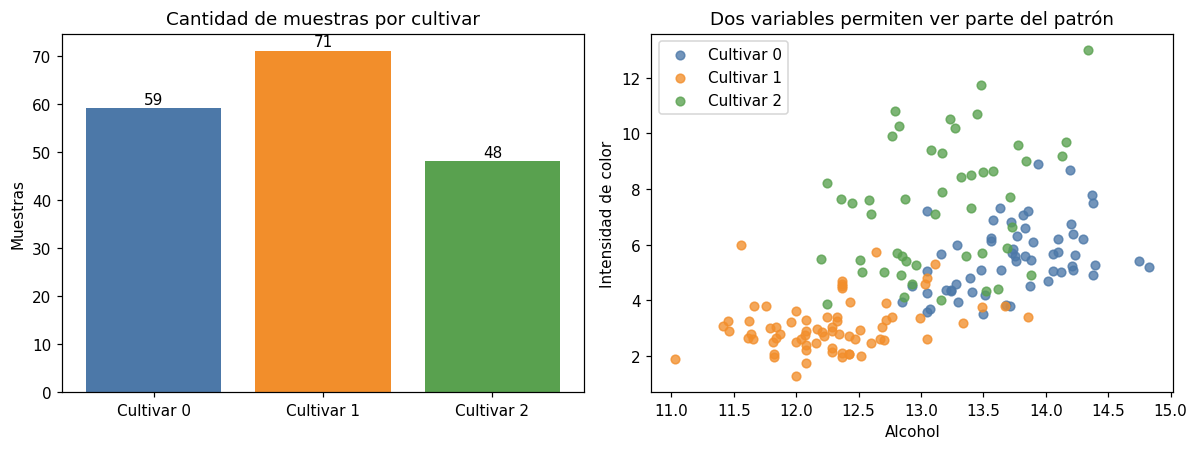

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

conteos = y.map(nombres_clases).value_counts().sort_index()
axes[0].bar(
    conteos.index,
    conteos.values,
    color=["#4C78A8", "#F28E2B", "#59A14F"],
)
axes[0].set_title("Cantidad de muestras por cultivar")
axes[0].set_ylabel("Muestras")
for posicion, valor in enumerate(conteos.values):
    axes[0].text(posicion, valor + 1, str(valor), ha="center")

for clase, color in zip(
    sorted(y.unique()),
    ["#4C78A8", "#F28E2B", "#59A14F"],
):
    axes[1].scatter(
        X.loc[y == clase, "alcohol"],
        X.loc[y == clase, "color_intensity"],
        label=nombres_clases[clase],
        alpha=0.78,
        s=32,
        color=color,
    )
axes[1].set_title("Dos variables permiten ver parte del patrón")
axes[1].set_xlabel("Alcohol")
axes[1].set_ylabel("Intensidad de color")
axes[1].legend()

plt.tight_layout()
plt.show()


El gráfico de dos variables muestra cierta separación, pero también superposición. Esto recuerda una idea importante: una visualización bidimensional no representa necesariamente todo lo que un modelo puede aprender de trece columnas. Tampoco demuestra que las clases puedan separarse perfectamente.

La distribución de clases no es idéntica, aunque ninguna categoría es extremadamente rara. Utilizaremos particiones estratificadas para conservar aproximadamente esas proporciones durante la evaluación.


## 3. Reservar el test antes de experimentar

Separaremos un 25% de las muestras para el test final. Toda comparación, lectura de parámetros y elección del procedimiento ocurrirá utilizando solamente el conjunto de desarrollo.

Este orden importa incluso en un laboratorio pequeño. Si consultáramos el test después de cada cambio, terminaríamos adaptando nuestras decisiones a ese conjunto. El test dejaría de representar datos no vistos y se convertiría, de hecho, en otra validación.


In [6]:
X_desarrollo, X_test, y_desarrollo, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=32,
)

resumen_particion = pd.DataFrame({
    "Conjunto": ["Desarrollo", "Test final"],
    "Filas": [len(X_desarrollo), len(X_test)],
    "Cultivar 0": [
        (y_desarrollo == 0).sum(),
        (y_test == 0).sum(),
    ],
    "Cultivar 1": [
        (y_desarrollo == 1).sum(),
        (y_test == 1).sum(),
    ],
    "Cultivar 2": [
        (y_desarrollo == 2).sum(),
        (y_test == 2).sum(),
    ],
})
resumen_particion


,Conjunto,Filas,Cultivar 0,Cultivar 1,Cultivar 2
0,Desarrollo,133,44,53,36
1,Test final,45,15,18,12


## 4. Construir una línea de base

Antes de incorporar un estimador nuevo, necesitamos referencias. La primera será `DummyClassifier`, que ignora las variables y reproduce una estrategia elemental. La segunda será una regresión logística, un modelo ya conocido.

La línea de base cumple dos funciones. Por un lado, comprueba que el problema contiene señal útil: un modelo entrenado debería superar una regla que no aprende relaciones entre las variables. Por otro, evita que interpretemos una técnica nueva en el vacío. La pregunta no será “¿funciona Extra Trees?”, sino “¿qué aporta frente a procedimientos más sencillos evaluados en las mismas particiones?”.

Usaremos F1 macro como métrica principal. Esta medida calcula F1 para cada clase y luego promedia los tres valores con el mismo peso. Así, una clase más numerosa no domina por completo el resultado.


In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=32,
)

referencia = Pipeline([
    ("imputación", SimpleImputer(strategy="median")),
    ("modelo", DummyClassifier(strategy="most_frequent")),
])

regresion = Pipeline([
    ("imputación", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler()),
    (
        "modelo",
        LogisticRegression(
            max_iter=3_000,
            random_state=32,
        ),
    ),
])

modelos_iniciales = {
    "Referencia": referencia,
    "Regresión logística": regresion,
}

filas = []
for nombre, procedimiento in modelos_iniciales.items():
    resultado = cross_validate(
        procedimiento,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        return_train_score=True,
    )
    filas.append({
        "modelo": nombre,
        "accuracy_validación": resultado["test_accuracy"].mean(),
        "f1_macro_validación": resultado["test_f1_macro"].mean(),
        "desvío_f1": resultado["test_f1_macro"].std(),
        "f1_macro_entrenamiento": resultado["train_f1_macro"].mean(),
    })

comparacion_inicial = (
    pd.DataFrame(filas)
    .set_index("modelo")
    .sort_values("f1_macro_validación", ascending=False)
)
comparacion_inicial


,accuracy_validación,f1_macro_validación,desvío_f1,f1_macro_entrenamiento
modelo,,,,
Regresión logística,0.970,0.970,0.027,1.000
Referencia,0.398,0.190,0.004,0.190


La regresión logística supera con claridad a la referencia. Esto no significa que el problema esté resuelto ni que la regresión sea la respuesta definitiva. Solo establece un punto de comparación razonable.

Ahora estamos en condiciones de explorar una herramienta no desarrollada en el libro. Mantendremos la misma validación y la misma métrica para que la comparación sea justa.


## 5. Aprender a leer la documentación de una herramienta nueva

Utilizaremos `ExtraTreesClassifier`, un modelo formado por muchos árboles. Su nombre completo puede traducirse como “árboles extremadamente aleatorios”. Se parece a Random Forest porque combina varias decisiones y produce una predicción conjunta, pero introduce más aleatoriedad al elegir los cortes de los árboles.

El objetivo de esta sección no es estudiar en profundidad el algoritmo. Practicaremos una estrategia para orientarnos:

1. comprobar qué versión de la biblioteca estamos utilizando;
2. leer la descripción breve de la clase;
3. revisar la firma del constructor;
4. identificar unos pocos parámetros relevantes;
5. construir un ejemplo mínimo;
6. examinar qué atributos aparecen después del entrenamiento;
7. volver a la documentación si un nombre o comportamiento no queda claro.

La versión es importante porque las bibliotecas cambian. Un parámetro puede incorporarse, modificar su valor predeterminado o dejar de existir. Un ejemplo encontrado en Internet no debería separarse de la versión para la que fue escrito.


In [8]:
versiones = pd.DataFrame({
    "Componente": ["Python", "scikit-learn"],
    "Versión": [
        platform.python_version(),
        sklearn.__version__,
    ],
})

descripcion_clase = " ".join(
    linea.strip()
    for linea in ExtraTreesClassifier.__doc__.splitlines()[:8]
    if linea.strip()
)

print(versiones.to_string(index=False))
print("\nDescripción inicial de la clase:")
print(descripcion_clase)


  Componente Versión
      Python 3.12.13
scikit-learn   1.8.0

Descripción inicial de la clase:
An extra-trees classifier. This class implements a meta estimator that fits a number of randomized decision trees (a.k.a. extra-trees) on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.


En Colab también podemos escribir `ExtraTreesClassifier?` o ejecutar `help(ExtraTreesClassifier)` para abrir la ayuda. La salida es extensa; no conviene leerla como una lista para memorizar. Primero buscamos:

- qué tipo de problema resuelve;
- qué formato espera en `X` e `y`;
- cuáles son los valores predeterminados;
- qué parámetros controlan complejidad, aleatoriedad y costo;
- qué métodos usaremos;
- qué atributos estarán disponibles después de entrenar.

`inspect.signature()` muestra la firma del constructor. `get_params()` devuelve los parámetros de un objeto concreto, incluidos los valores que no escribimos y que, por lo tanto, quedaron en su configuración predeterminada.


In [9]:
firma = str(inspect.signature(ExtraTreesClassifier))
print("Firma del constructor:")
print(firma)

modelo_para_explorar = ExtraTreesClassifier(random_state=32)
parametros = modelo_para_explorar.get_params()

parametros_seleccionados = pd.DataFrame({
    "Parámetro": [
        "n_estimators",
        "criterion",
        "max_depth",
        "min_samples_leaf",
        "max_features",
        "bootstrap",
        "random_state",
        "n_jobs",
    ],
    "Valor actual": [
        parametros["n_estimators"],
        parametros["criterion"],
        parametros["max_depth"],
        parametros["min_samples_leaf"],
        parametros["max_features"],
        parametros["bootstrap"],
        parametros["random_state"],
        parametros["n_jobs"],
    ],
})
parametros_seleccionados


Firma del constructor:
(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=False, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)


,Parámetro,Valor actual
0,n_estimators,100
1,criterion,gini
2,max_depth,None
3,min_samples_leaf,1
4,max_features,sqrt
5,bootstrap,False
6,random_state,32
7,n_jobs,None


### Parámetros y atributos no son lo mismo

Un **parámetro** se define antes de entrenar. Por ejemplo, `n_estimators` indica cuántos árboles se construirán y `min_samples_leaf` establece la cantidad mínima de muestras que puede contener una hoja.

Un **atributo aprendido** aparece después de llamar a `fit`. `classes_` guarda las clases conocidas, `n_features_in_` indica cuántas columnas recibió el estimador y `feature_importances_` resume cuánto participó cada variable en las divisiones de los árboles.

El guion bajo final es una convención frecuente de `scikit-learn`: ayuda a reconocer información que el modelo no poseía antes del entrenamiento. Aun así, no todos los estimadores ofrecen los mismos atributos. La documentación de cada clase es la fuente que debemos consultar.


In [10]:
modelo_para_explorar.fit(X_desarrollo, y_desarrollo)

atributos_aprendidos = pd.DataFrame({
    "Atributo": ["classes_", "n_features_in_", "feature_importances_"],
    "Contenido resumido": [
        str(modelo_para_explorar.classes_),
        str(modelo_para_explorar.n_features_in_),
        (
            f"Vector de {len(modelo_para_explorar.feature_importances_)} "
            f"importancias; suma = "
            f"{modelo_para_explorar.feature_importances_.sum():.3f}"
        ),
    ],
})
atributos_aprendidos


,Atributo,Contenido resumido
0,classes_,[0 1 2]
1,n_features_in_,13
2,feature_importances_,Vector de 13 importancias; suma = 1.000


La existencia de `feature_importances_` no convierte automáticamente al modelo en una explicación causal. Como vimos en el capítulo sobre interpretación, una importancia describe el uso de una variable dentro de un procedimiento y puede cambiar ante variables correlacionadas, nuevas muestras o configuraciones diferentes.

Leer documentación no significa aceptar cada salida sin preguntas. Significa conocer qué produce la herramienta para poder interpretarla dentro del problema.


## 6. Incorporar el estimador a un pipeline

Aunque el dataset actual no tiene faltantes, mantendremos una imputación dentro del pipeline. Esto deja explícito qué ocurriría si apareciera una medición ausente y permite conservar el procedimiento completo.

No incluiremos escalado para Extra Trees. Los árboles comparan valores mediante cortes y no calculan distancias entre variables, por lo que la diferencia de unidades no cumple el mismo papel que en regresión logística, KNN o SVM.

Comenzaremos con una configuración cercana a la predeterminada. No buscaremos todavía el mejor parámetro. Primero comprobaremos que el estimador se integra al flujo y lo compararemos mediante los mismos folds.


In [11]:
extra_trees_inicial = Pipeline([
    ("imputación", SimpleImputer(strategy="median")),
    (
        "modelo",
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=32,
            n_jobs=-1,
        ),
    ),
])

modelos_comparados = {
    **modelos_iniciales,
    "Extra Trees": extra_trees_inicial,
}

filas = []
for nombre, procedimiento in modelos_comparados.items():
    resultado = cross_validate(
        procedimiento,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        return_train_score=True,
    )
    filas.append({
        "modelo": nombre,
        "accuracy_validación": resultado["test_accuracy"].mean(),
        "f1_macro_validación": resultado["test_f1_macro"].mean(),
        "desvío_f1": resultado["test_f1_macro"].std(),
        "f1_macro_entrenamiento": resultado["train_f1_macro"].mean(),
    })

comparacion_modelos = (
    pd.DataFrame(filas)
    .set_index("modelo")
    .sort_values("f1_macro_validación", ascending=False)
)
comparacion_modelos


,accuracy_validación,f1_macro_validación,desvío_f1,f1_macro_entrenamiento
modelo,,,,
Extra Trees,0.993,0.992,0.015,1.000
Regresión logística,0.970,0.970,0.027,1.000
Referencia,0.398,0.190,0.004,0.190


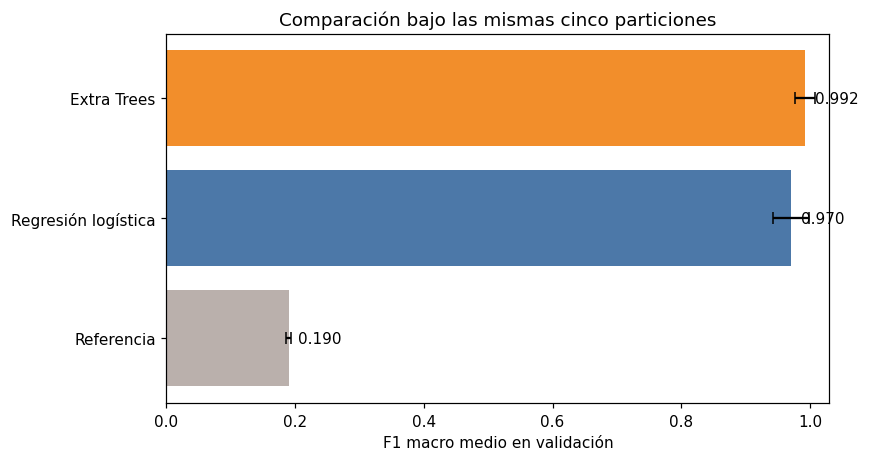

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.3))

orden = comparacion_modelos.sort_values(
    "f1_macro_validación"
)
colores = [
    "#BAB0AC" if nombre == "Referencia"
    else "#4C78A8" if nombre == "Regresión logística"
    else "#F28E2B"
    for nombre in orden.index
]

ax.barh(
    orden.index,
    orden["f1_macro_validación"],
    xerr=orden["desvío_f1"],
    color=colores,
    capsize=4,
)
ax.set_xlim(0, 1.03)
ax.set_xlabel("F1 macro medio en validación")
ax.set_title("Comparación bajo las mismas cinco particiones")
for posicion, valor in enumerate(orden["f1_macro_validación"]):
    ax.text(valor + 0.015, posicion, f"{valor:.3f}", va="center")

plt.tight_layout()
plt.show()


En esta ejecución, Extra Trees alcanza un F1 macro medio de `0,992`, frente a `0,970` de la regresión logística y `0,190` de la referencia. La nueva herramienta aporta una mejora en estas particiones, pero el resultado todavía no explica por qué ni garantiza que sea estable en otros datos. En un conjunto tan pequeño, la variabilidad entre folds merece atención. Una diferencia de pocas milésimas no debería convertirse en una afirmación de superioridad general.

También debemos observar la distancia entre entrenamiento y validación. Extra Trees obtiene `1,000` en entrenamiento y `0,992` en validación. La brecha es pequeña, pero confirma que el ensamble sin restricciones puede ajustar perfectamente las muestras conocidas. Eso nos lleva a formular una hipótesis concreta sobre la complejidad.


## 7. Modificar un parámetro con una hipótesis

`min_samples_leaf` indica cuántas muestras, como mínimo, puede contener una hoja. Con el valor `1`, un árbol puede crear regiones muy específicas. Si lo aumentamos, cada hoja deberá reunir más observaciones y el modelo será menos flexible.

Antes de ejecutar, formulamos esta expectativa:

> **Hipótesis:** al aumentar `min_samples_leaf`, el F1 de entrenamiento debería bajar porque los árboles tendrán menos libertad para memorizar detalles. El F1 de validación podría mejorar al principio si reducimos sobreajuste, pero debería empeorar si la restricción se vuelve excesiva.

La hipótesis no afirma de antemano cuál será el mejor valor. Describe un mecanismo esperado y permite interpretar la curva después de verla. Probar parámetros con una idea previa produce más aprendizaje que cambiar números hasta encontrar el resultado más alto.


In [13]:
valores_hoja = [1, 2, 4, 8, 12, 16, 20, 24, 30, 40]
resultados_hoja = []

for minimo_hoja in valores_hoja:
    procedimiento = Pipeline([
        ("imputación", SimpleImputer(strategy="median")),
        (
            "modelo",
            ExtraTreesClassifier(
                n_estimators=300,
                min_samples_leaf=minimo_hoja,
                random_state=32,
                n_jobs=-1,
            ),
        ),
    ])
    resultado = cross_validate(
        procedimiento,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring="f1_macro",
        return_train_score=True,
    )
    resultados_hoja.append({
        "min_samples_leaf": minimo_hoja,
        "f1_entrenamiento": resultado["train_score"].mean(),
        "f1_validación": resultado["test_score"].mean(),
        "desvío_validación": resultado["test_score"].std(),
    })

experimento_hoja = pd.DataFrame(resultados_hoja)
experimento_hoja


,min_samples_leaf,f1_entrenamiento,f1_validación,desvío_validación
0,1,1.000,0.992,0.015
1,2,1.000,0.992,0.015
2,4,1.000,0.992,0.015
3,8,0.992,0.992,0.015
4,12,0.991,0.993,0.014
5,16,0.987,0.993,0.014
6,20,0.993,0.992,0.016
7,24,0.975,0.984,0.020
8,30,0.793,0.791,0.063
9,40,0.548,0.541,0.029


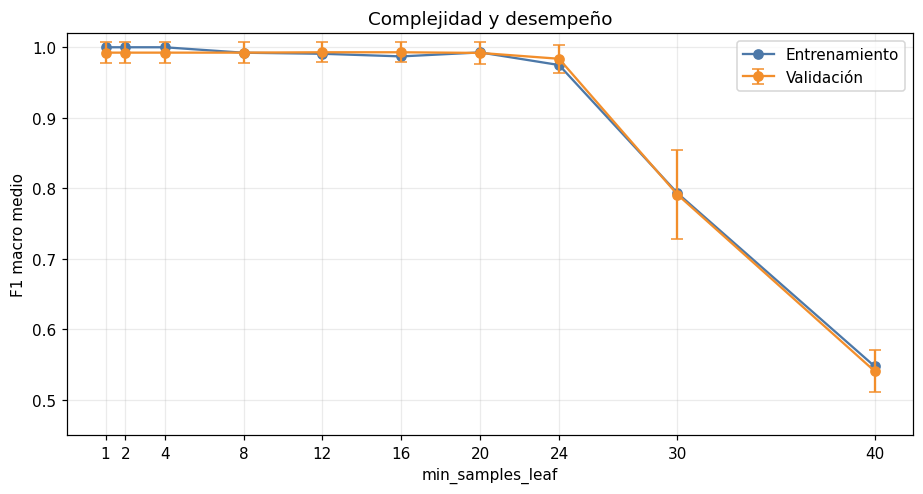

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))

ax.plot(
    experimento_hoja["min_samples_leaf"],
    experimento_hoja["f1_entrenamiento"],
    marker="o",
    label="Entrenamiento",
    color="#4C78A8",
)
ax.errorbar(
    experimento_hoja["min_samples_leaf"],
    experimento_hoja["f1_validación"],
    yerr=experimento_hoja["desvío_validación"],
    marker="o",
    capsize=4,
    label="Validación",
    color="#F28E2B",
)
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("F1 macro medio")
ax.set_title("Complejidad y desempeño")
ax.set_xticks(valores_hoja)
ax.set_ylim(0.45, 1.02)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


La curva permite contrastar la expectativa con los resultados. Entre `1` y `24`, el F1 de validación permanece muy alto; el modelo tolera cierta restricción sin perder capacidad de generalización. Con `30`, en cambio, baja aproximadamente a `0,791`, y con `40` cae a `0,541`. Cada hoja debe reunir tantas muestras que el ensamble ya no puede representar separaciones necesarias.

El F1 de entrenamiento también desciende, desde `1,000` hasta cerca de `0,548`, por lo que la primera parte de la hipótesis queda respaldada en este experimento. Las pequeñas fluctuaciones dentro de la zona alta deben leerse junto con su desvío. En un dataset reducido, una diferencia de milésimas no constituye una victoria concluyente.

Elegiremos el valor con mayor F1 macro medio dentro de los folds. Esta regla es transparente, aunque no es la única posible. Si varios valores quedan prácticamente empatados, también podríamos preferir uno más simple o repetir el experimento con validaciones adicionales.

La elección todavía pertenece al conjunto de desarrollo. El test final permanece sin consultar.


In [15]:
mejor_fila = experimento_hoja.loc[
    experimento_hoja["f1_validación"].idxmax()
]
mejor_minimo_hoja = int(mejor_fila["min_samples_leaf"])

print(
    "Valor elegido de min_samples_leaf:",
    mejor_minimo_hoja,
)
print(
    "F1 macro medio de validación:",
    f"{mejor_fila['f1_validación']:.3f}",
)
print(
    "Desvío entre folds:",
    f"{mejor_fila['desvío_validación']:.3f}",
)


Valor elegido de min_samples_leaf: 12
F1 macro medio de validación: 0.993
Desvío entre folds: 0.014


## 8. Entrenar el procedimiento elegido y consultar el test

Ahora entrenaremos el pipeline elegido con todas las muestras de desarrollo. Recién después calcularemos sus predicciones sobre el test reservado.

El resultado del test no se usará para volver atrás y probar otras configuraciones. Su función es ofrecer una estimación final bajo las decisiones que ya tomamos. En un proyecto nuevo, un único test pequeño sigue teniendo incertidumbre; por eso conservaremos tanto la validación como el resultado final y evitaremos presentar una cifra como verdad universal.


In [16]:
pipeline_final = Pipeline([
    ("imputación", SimpleImputer(strategy="median")),
    (
        "modelo",
        ExtraTreesClassifier(
            n_estimators=300,
            min_samples_leaf=mejor_minimo_hoja,
            random_state=32,
            n_jobs=-1,
        ),
    ),
])

pipeline_final.fit(X_desarrollo, y_desarrollo)
pred_test = pipeline_final.predict(X_test)
proba_test = pipeline_final.predict_proba(X_test)

metricas_test = pd.DataFrame({
    "Métrica": ["Accuracy", "F1 macro"],
    "Test final": [
        accuracy_score(y_test, pred_test),
        f1_score(y_test, pred_test, average="macro"),
    ],
})
metricas_test


,Métrica,Test final
0,Accuracy,0.956
1,F1 macro,0.959


              precision    recall  f1-score   support

  Cultivar 0      0.933     0.933     0.933        15
  Cultivar 1      0.944     0.944     0.944        18
  Cultivar 2      1.000     1.000     1.000        12

    accuracy                          0.956        45
   macro avg      0.959     0.959     0.959        45
weighted avg      0.956     0.956     0.956        45



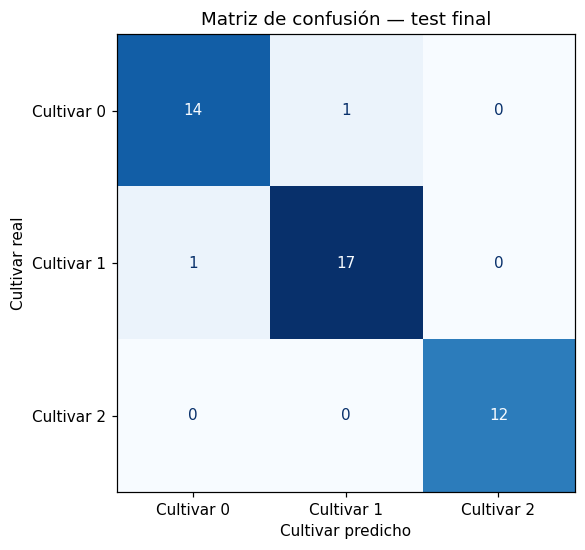

In [17]:
print(
    classification_report(
        y_test,
        pred_test,
        target_names=[
            nombres_clases[i]
            for i in sorted(nombres_clases)
        ],
        digits=3,
    )
)

fig, ax = plt.subplots(figsize=(5.8, 5.1))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_test,
    display_labels=[
        nombres_clases[i]
        for i in sorted(nombres_clases)
    ],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Matriz de confusión — test final")
ax.set_xlabel("Cultivar predicho")
ax.set_ylabel("Cultivar real")

plt.tight_layout()
plt.show()


### Revisar casos individuales

Las métricas resumen, pero los errores muestran dónde se mezclan las clases. Calcularemos la confianza como la probabilidad más alta asignada por el modelo y observaremos primero los errores más confiados.

Una probabilidad alta no garantiza que la predicción sea correcta. En modelos basados en árboles, las probabilidades surgen de la proporción de votos o distribuciones dentro del ensamble y pueden necesitar calibración si se utilizarán como probabilidades operativas. Aquí servirán solamente para ordenar la revisión.


In [18]:
revision_errores = X_test.copy()
revision_errores["real"] = y_test.map(nombres_clases)
revision_errores["predicho"] = pd.Series(
    pred_test,
    index=X_test.index,
).map(nombres_clases)
revision_errores["confianza"] = proba_test.max(axis=1)
revision_errores["correcto"] = (
    revision_errores["real"]
    == revision_errores["predicho"]
)

errores = (
    revision_errores.loc[
        ~revision_errores["correcto"],
        [
            "real",
            "predicho",
            "confianza",
            "alcohol",
            "malic_acid",
            "color_intensity",
            "proline",
        ],
    ]
    .sort_values("confianza", ascending=False)
)

print(f"Errores en el test: {len(errores)} de {len(X_test)}")
errores.head(10)


Errores en el test: 2 de 45


,real,predicho,confianza,alcohol,malic_acid,color_intensity,proline
73,Cultivar 1,Cultivar 0,0.553,12.990,1.670,3.350,985.000
43,Cultivar 0,Cultivar 1,0.403,13.240,3.980,4.360,680.000


El test obtiene un F1 macro de `0,959`, algo menor que el `0,993` medio observado durante la validación. De las 45 muestras, 43 se clasifican correctamente. Los dos errores confunden los cultivares 0 y 1; el cultivar 2 queda completamente reconocido en este test.

Con solo dos errores no conviene construir una teoría completa sobre sus causas. Sí podemos formular preguntas: ¿presentan valores intermedios?, ¿hay mediciones atípicas?, ¿la etiqueta podría ser dudosa?, ¿faltan variables relevantes?

La revisión transforma un resultado agregado en nuevas hipótesis. Algunas podrán responderse con los datos actuales y otras exigirán conocimiento del dominio o una recolección adicional.


## 9. Guardar y recuperar el pipeline completo

Hasta ahora el modelo vive en la memoria de esta sesión. Si cerráramos el entorno, se perdería. `joblib.dump()` permite guardar el objeto entrenado y `joblib.load()` recuperarlo más tarde.

Guardaremos el **pipeline completo**, no solamente `ExtraTreesClassifier`. De ese modo, la imputación y el orden de los pasos viajan junto con el modelo. Esta práctica reduce el riesgo de aplicar en producción una transformación diferente de la utilizada durante el entrenamiento.

Sin embargo, el archivo no contiene todo el contexto del proyecto. No explica por sí solo de dónde vinieron los datos, qué variable se predice, qué métrica se eligió, qué versión de la biblioteca se utilizó ni qué usos se consideran inadecuados. Por eso acompañaremos el archivo con un registro mínimo.


In [19]:
ruta_modelo = Path("pipeline_vinos_cuaderno32.joblib")
joblib.dump(pipeline_final, ruta_modelo)

pipeline_recuperado = joblib.load(ruta_modelo)
pred_recuperada = pipeline_recuperado.predict(X_test)

print("Archivo creado:", ruta_modelo)
print("Tamaño en bytes:", ruta_modelo.stat().st_size)
print(
    "Predicciones idénticas después de cargar:",
    np.array_equal(pred_test, pred_recuperada),
)


Archivo creado: pipeline_vinos_cuaderno32.joblib
Tamaño en bytes: 346746
Predicciones idénticas después de cargar: True


Que las predicciones coincidan demuestra que el estado necesario para repetir esta inferencia quedó guardado. No demuestra que el archivo sea portable a cualquier entorno para siempre.

Los formatos basados en serialización dependen de las clases y versiones con las que fueron creados. Además, **nunca debe cargarse un archivo `joblib` de origen desconocido**, porque la carga puede ejecutar código. En un sistema real hay que controlar procedencia, permisos, versiones y almacenamiento.


In [20]:
registro_modelo = {
    "nombre": "Clasificador de cultivares — laboratorio",
    "fecha_entrenamiento": date.today().isoformat(),
    "dataset": "Wine incluido en scikit-learn",
    "unidad_analisis": "Una muestra de vino",
    "objetivo": "Cultivar 0, 1 o 2",
    "filas_desarrollo": len(X_desarrollo),
    "filas_test": len(X_test),
    "columnas_esperadas": list(X_desarrollo.columns),
    "modelo": "ExtraTreesClassifier",
    "min_samples_leaf": mejor_minimo_hoja,
    "f1_macro_validacion": round(
        float(mejor_fila["f1_validación"]), 4
    ),
    "f1_macro_test": round(
        float(f1_score(y_test, pred_test, average="macro")),
        4,
    ),
    "python": platform.python_version(),
    "scikit_learn": sklearn.__version__,
    "uso_previsto": (
        "Ejemplo didáctico; no validado para decisiones reales"
    ),
}

print(json.dumps(registro_modelo, indent=2, ensure_ascii=False))


{
  "nombre": "Clasificador de cultivares — laboratorio",
  "fecha_entrenamiento": "2026-07-27",
  "dataset": "Wine incluido en scikit-learn",
  "unidad_analisis": "Una muestra de vino",
  "objetivo": "Cultivar 0, 1 o 2",
  "filas_desarrollo": 133,
  "filas_test": 45,
  "columnas_esperadas": [
    "alcohol",
    "malic_acid",
    "ash",
    "alcalinity_of_ash",
    "magnesium",
    "total_phenols",
    "flavanoids",
    "nonflavanoid_phenols",
    "proanthocyanins",
    "color_intensity",
    "hue",
    "od280/od315_of_diluted_wines",
    "proline"
  ],
  "modelo": "ExtraTreesClassifier",
  "min_samples_leaf": 12,
  "f1_macro_validacion": 0.9929,
  "f1_macro_test": 0.9593,
  "python": "3.12.13",
  "scikit_learn": "1.8.0",
  "uso_previsto": "Ejemplo didáctico; no validado para decisiones reales"
}


El registro es deliberadamente breve, pero ya responde preguntas que el archivo del modelo no puede contestar. En un proyecto real podría ampliarse con identificadores de versiones de datos y código, responsables, métricas por grupo, restricciones conocidas, fecha prevista de revisión y procedimiento de retirada.

Este es un primer contacto con MLOps: no una plataforma completa, sino la idea de que un modelo utilizado en el tiempo necesita versiones, trazabilidad, controles y mantenimiento.


## 10. Un modelo puede funcionar aunque los datos hayan cambiado

Imaginemos que tiempo después llega un nuevo lote de muestras. El pipeline puede cargarlo y producir predicciones siempre que encuentre las columnas esperadas. Pero el funcionamiento técnico no garantiza que los nuevos datos se parezcan a los utilizados durante el entrenamiento.

Simularemos un lote con cambios deliberados en algunas mediciones. No representa una transformación química real ni un cuarto cultivar: solo crea un escenario controlado para observar una **deriva de datos**.

Mediremos cada cambio de media en unidades del desvío estándar de entrenamiento:

$$
\text{cambio estandarizado} =
\frac{\text{media nueva} - \text{media de entrenamiento}}
{\text{desvío de entrenamiento}}
$$

Un valor cercano a cero indica medias similares. Un valor de `1` significa que la nueva media se desplazó aproximadamente un desvío estándar. Esta medida es una alerta sencilla, no una prueba completa de que toda la distribución haya cambiado.


In [21]:
X_nuevo = X_test.copy()

# Cambios artificiales para la demostración.
X_nuevo["alcohol"] = (
    X_nuevo["alcohol"]
    + 0.80 * X_desarrollo["alcohol"].std()
)
X_nuevo["proline"] = (
    X_nuevo["proline"]
    - 0.70 * X_desarrollo["proline"].std()
)
X_nuevo["color_intensity"] = (
    X_nuevo["color_intensity"]
    + 0.45 * X_desarrollo["color_intensity"].std()
)

cambio_estandarizado = (
    (X_nuevo.mean() - X_desarrollo.mean())
    / X_desarrollo.std()
).sort_values(key=np.abs, ascending=False)

comparacion_medias = pd.DataFrame({
    "media_entrenamiento": X_desarrollo.mean(),
    "media_lote_nuevo": X_nuevo.mean(),
    "cambio_estandarizado": cambio_estandarizado,
}).sort_values(
    "cambio_estandarizado",
    key=np.abs,
    ascending=False,
)

comparacion_medias.head(8)


,media_entrenamiento,media_lote_nuevo,cambio_estandarizado
proline,750.158,511.618,-0.740
alcohol,13.043,13.518,0.592
color_intensity,5.124,5.914,0.338
proanthocyanins,1.633,1.466,-0.291
hue,0.972,0.913,-0.254
malic_acid,2.279,2.506,0.213
od280/od315_of_diluted_wines,2.641,2.526,-0.167
ash,2.357,2.394,0.140


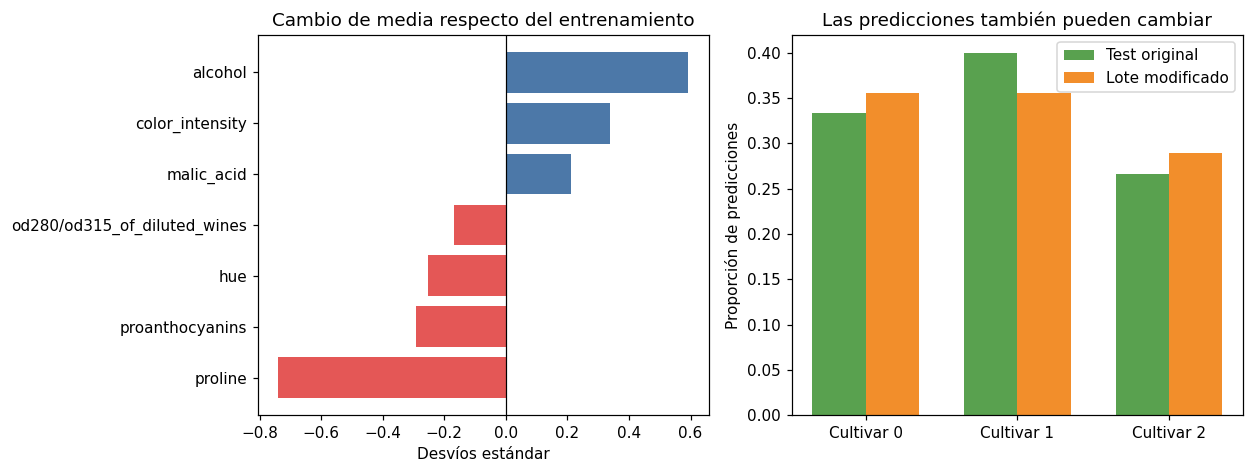

In [22]:
pred_nuevo = pipeline_recuperado.predict(X_nuevo)

proporcion_test = (
    pd.Series(pred_test)
    .value_counts(normalize=True)
    .reindex(sorted(nombres_clases), fill_value=0)
)
proporcion_nuevo = (
    pd.Series(pred_nuevo)
    .value_counts(normalize=True)
    .reindex(sorted(nombres_clases), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

cambios_grafico = cambio_estandarizado.head(7).sort_values()
axes[0].barh(
    cambios_grafico.index,
    cambios_grafico.values,
    color=[
        "#E45756" if valor < 0 else "#4C78A8"
        for valor in cambios_grafico.values
    ],
)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Cambio de media respecto del entrenamiento")
axes[0].set_xlabel("Desvíos estándar")

posiciones = np.arange(len(nombres_clases))
ancho = 0.35
axes[1].bar(
    posiciones - ancho / 2,
    proporcion_test.values,
    width=ancho,
    label="Test original",
    color="#59A14F",
)
axes[1].bar(
    posiciones + ancho / 2,
    proporcion_nuevo.values,
    width=ancho,
    label="Lote modificado",
    color="#F28E2B",
)
axes[1].set_xticks(
    posiciones,
    [nombres_clases[i] for i in sorted(nombres_clases)],
)
axes[1].set_ylabel("Proporción de predicciones")
axes[1].set_title("Las predicciones también pueden cambiar")
axes[1].legend()

plt.tight_layout()
plt.show()


El pipeline produjo predicciones sin errores, pero las medias de varias columnas y la distribución de clases predichas cambiaron. La media de `proline` se desplazó aproximadamente `-0,74` desvíos estándar, la de `alcohol` `+0,59` y la de intensidad de color `+0,34`. Esa es precisamente la advertencia: **“el sistema sigue funcionando” y “el modelo sigue siendo válido” son afirmaciones diferentes**.

Como este lote simulado no posee etiquetas nuevas confiables, no podemos calcular su F1 real. Detectar deriva en `X` no demuestra que el desempeño haya empeorado; indica que una condición del entrenamiento dejó de cumplirse y que conviene investigar. Para saber cómo rinde el modelo necesitaríamos obtener resultados reales posteriores, revisar su calidad y evaluar nuevamente.

Un monitoreo más completo podría revisar distribuciones enteras, categorías nuevas, faltantes, valores fuera de rango, cambios en la proporción de predicciones y, cuando las etiquetas estén disponibles, métricas de desempeño. También debería definir quién recibe la alerta y qué acción se toma.


## 11. Mapa de caminos que continúan

Este laboratorio profundizó una práctica de MLOps, pero el capítulo abre varios caminos. Cada uno cambia el tipo de datos, la forma de validar o la pregunta que intentamos responder. El primer paso debería ser acotado: una experiencia pequeña y comprensible antes de avanzar hacia sistemas grandes.

| Camino | Qué cambia respecto de este cuaderno | Primera práctica razonable |
|---|---|---|
| Deep Learning | El modelo aprende representaciones mediante capas y entrenamiento iterativo | Comparar una red pequeña con un modelo clásico sobre el mismo problema |
| Procesamiento de lenguaje natural | La entrada es texto y debe transformarse en una representación numérica | Clasificar mensajes con TF-IDF y un modelo lineal |
| Series temporales | El orden temporal forma parte del problema y limita la validación | Predecir el siguiente período usando una separación cronológica |
| Sistemas de recomendación | La salida ordena opciones relevantes para una persona o contexto | Comparar popularidad global con recomendaciones por similitud |
| MLOps | El modelo debe versionarse, observarse y mantenerse después de entrenar | Guardar un pipeline, registrar su contexto y revisar un lote nuevo |
| Ética y regulación | Importan usos, derechos, riesgos, trazabilidad y responsabilidades | Elaborar una ficha de riesgos y usos no recomendados antes de desplegar |

La tabla no es un programa de estudios completo. Su función es transformar temas muy amplios en una primera experiencia que pueda evaluarse y comprenderse.


## 12. Diseñar un próximo paso personal

Un plan útil no debería limitarse a “aprender Deep Learning” o “estudiar NLP”. Conviene formular un problema pequeño, identificar conocimientos previos, elegir una evidencia de avance y reconocer riesgos.

La siguiente celda funciona como plantilla editable. El ejemplo propone iniciar NLP mediante clasificación de textos, pero podés reemplazarlo por cualquiera de los caminos anteriores.


In [23]:
plan_personal = {
    "tema": "Procesamiento de lenguaje natural",
    "problema_acotado": (
        "Clasificar mensajes breves en tres categorías"
    ),
    "primer_dataset": (
        "Un conjunto documentado, pequeño y con etiquetas revisadas"
    ),
    "conocimientos_necesarios": [
        "Limpieza básica de texto",
        "TfidfVectorizer",
        "Pipeline con un modelo lineal",
        "F1 por clase y matriz de confusión",
    ],
    "primera_comparación": (
        "DummyClassifier frente a TF-IDF + regresión logística"
    ),
    "evidencia_de_avance": (
        "Poder explicar el flujo y analizar cinco errores"
    ),
    "riesgos_a_revisar": [
        "Etiquetas ambiguas",
        "Clases poco representadas",
        "Datos personales en los textos",
        "Diferencias de lenguaje entre entrenamiento y uso",
    ],
    "alcance_inicial": (
        "Un notebook reproducible; sin despliegue automático"
    ),
}

pd.DataFrame(
    {
        "Elemento": plan_personal.keys(),
        "Decisión": [
            ", ".join(valor)
            if isinstance(valor, list)
            else valor
            for valor in plan_personal.values()
        ],
    }
)


,Elemento,Decisión
0,tema,Procesamiento de lenguaje natural
1,problema_acotado,Clasificar mensajes breves en tres categorías
2,primer_dataset,"Un conjunto documentado, pequeño y con etiquet..."
3,conocimientos_necesarios,"Limpieza básica de texto, TfidfVectorizer, Pip..."
4,primera_comparación,DummyClassifier frente a TF-IDF + regresión lo...
5,evidencia_de_avance,Poder explicar el flujo y analizar cinco errores
6,riesgos_a_revisar,"Etiquetas ambiguas, Clases poco representadas,..."
7,alcance_inicial,Un notebook reproducible; sin despliegue autom...


## 13. Actividad modificable

Elegí uno de los siguientes cambios y escribí primero qué esperás que ocurra:

1. Modificá `n_estimators` y medí cuánto cambia el tiempo y la variabilidad.
2. Compará `max_features="sqrt"` con `max_features=None`.
3. Reemplazá Extra Trees por otro estimador no estudiado y repetí la rutina de documentación.
4. Creá un lote nuevo con cambios más pequeños y definí qué señales revisarías.
5. Completá el plan personal para un tema que realmente quieras continuar.

Registrá la hipótesis, la modificación, la evidencia obtenida y la conclusión. Si el resultado contradice tu expectativa, no es un fracaso: es información que obliga a revisar la explicación inicial.

Una estructura posible es:

```text
Hipótesis:

Cambio realizado:

Métrica o evidencia observada:

Resultado:

Qué probaría después:
```


## 14. Síntesis

En este cuaderno comenzamos con un problema desconocido, identificamos qué representaban sus filas y etiquetas, reservamos un test y construimos referencias. Recién entonces consultamos la documentación de Extra Trees, diferenciamos parámetros y atributos, incorporamos el modelo a un pipeline y estudiamos un hiperparámetro mediante una hipótesis explícita.

Después evaluamos una sola vez sobre el test, revisamos errores y guardamos el procedimiento completo. La carga del archivo reprodujo las predicciones, pero el lote modificado mostró por qué esa comprobación técnica no alcanza: los datos pueden cambiar y el modelo puede continuar respondiendo aunque ya no sepamos si mantiene su desempeño.

Seguir aprendiendo Machine Learning no consiste solamente en sumar algoritmos. También implica aprender a orientarse ante herramientas nuevas, diseñar comparaciones justas, documentar decisiones, reconocer incertidumbre y transformar resultados inesperados en mejores preguntas.


## Para pensar

1. ¿Por qué conviene construir una línea de base antes de probar un estimador desconocido?
2. ¿Qué diferencia existe entre un parámetro como `min_samples_leaf` y un atributo como `classes_`?
3. ¿Qué aprendemos cuando un resultado contradice la hipótesis formulada antes del experimento?
4. ¿Por qué recuperar un pipeline y reproducir sus predicciones no demuestra que siga siendo adecuado?
5. ¿Qué tema elegirías para continuar y cuál sería una primera práctica suficientemente acotada?


---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
